BUSINESS SALES INTELLIGENCE DASHBOARD WITH PREDICTIVE ANALYTICS

In [ ]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# LOAD DATASET

df=pd.read_csv("/content/Business_sales_data.csv")
df

,Order_ID,Date,Region,Category,Product,Sales,Quantity,Discount,Profit
0,1,2025-01-01,South,Electronics,Headphones,1200,2,10,180
1,2,2025-01-02,North,Clothing,T-Shirt,800,4,5,120
2,3,2025-01-03,West,Home,Chair,3500,1,15,400
3,4,2025-01-04,East,Electronics,Smartphone,15000,1,5,1200
4,5,2025-01-05,South,Clothing,Jeans,2000,2,10,250
5,6,2025-01-06,North,Home,Table,4200,1,20,500
6,7,2025-01-07,West,Electronics,Laptop,55000,1,8,4000
7,8,2025-01-08,East,Clothing,Shirt,900,3,5,150
8,9,2025-01-09,South,Home,Blender,1800,2,12,220
9,10,2025-01-10,North,Electronics,Mouse,700,5,5,90


In [ ]:
# BASIC INFO

df.head()

,Order_ID,Date,Region,Category,Product,Sales,Quantity,Discount,Profit
0,1,2025-01-01,South,Electronics,Headphones,1200,2,10,180
1,2,2025-01-02,North,Clothing,T-Shirt,800,4,5,120
2,3,2025-01-03,West,Home,Chair,3500,1,15,400
3,4,2025-01-04,East,Electronics,Smartphone,15000,1,5,1200
4,5,2025-01-05,South,Clothing,Jeans,2000,2,10,250


In [ ]:
df.tail()

,Order_ID,Date,Region,Category,Product,Sales,Quantity,Discount,Profit
45,46,2025-02-16,North,Electronics,Mouse,750,5,5,95
46,47,2025-02-17,West,Clothing,Jacket,3200,1,10,370
47,48,2025-02-18,East,Home,Mixer,2100,1,10,260
48,49,2025-02-19,South,Electronics,Monitor,8200,1,12,920
49,50,2025-02-20,North,Clothing,Shirt,980,2,5,135


In [ ]:
df.columns

Index(['Order_ID', 'Date', 'Region', 'Category', 'Product', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.shape

(50, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  50 non-null     int64 
 1   Date      50 non-null     object
 2   Region    50 non-null     object
 3   Category  50 non-null     object
 4   Product   50 non-null     object
 5   Sales     50 non-null     int64 
 6   Quantity  50 non-null     int64 
 7   Discount  50 non-null     int64 
 8   Profit    50 non-null     int64 
dtypes: int64(5), object(4)
memory usage: 3.6+ KB


In [ ]:
df.describe()

,Order_ID,Sales,Quantity,Discount,Profit
count,50.00000,50.00000,50.000000,50.000000,50.000000
mean,25.50000,10076.60000,1.740000,10.160000,974.600000
std,14.57738,14887.45844,1.103057,4.432533,1256.821323
min,1.00000,700.00000,1.000000,5.000000,90.000000
25%,13.25000,1300.00000,1.000000,5.000000,180.000000
50%,25.50000,3100.00000,1.000000,10.000000,360.000000
75%,37.75000,11750.00000,2.000000,12.000000,980.000000
max,50.00000,60000.00000,5.000000,20.000000,4500.000000


In [ ]:
# CHECK MISSING VALUES

df.isnull().sum()

,0
Order_ID,0
Date,0
Region,0
Category,0
Product,0
Sales,0
Quantity,0
Discount,0
Profit,0


In [ ]:
# CONVERT DATE COLUMN

df['Date']=pd.to_datetime(df['Date'])

In [ ]:
# FEATURE ENGINEERING

df_encoded = pd.get_dummies(df, columns=['Region', 'Category', 'Product'], drop_first=True)

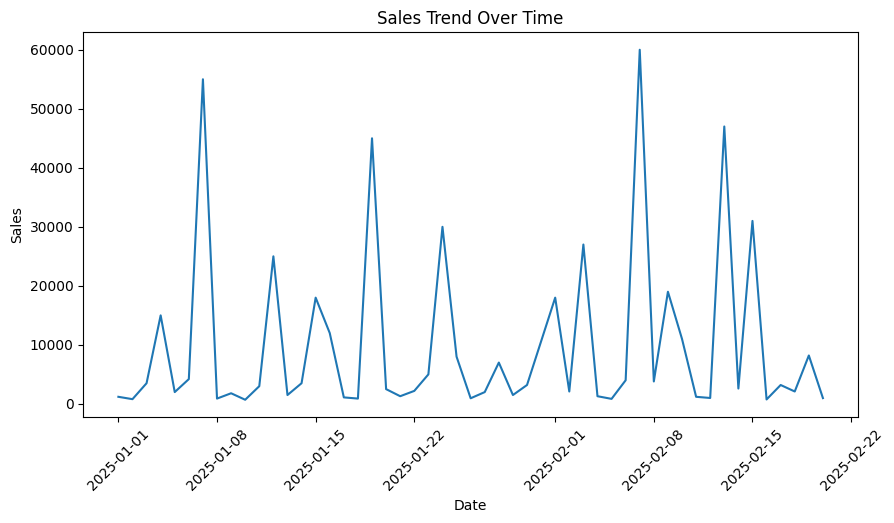

In [ ]:
# SALES OVERVIEW

plt.figure(figsize=(10,5))
sns.lineplot(x='Date', y='Sales', data=df)
plt.title("Sales Trend Over Time")
plt.xticks(rotation=45)
plt.show()

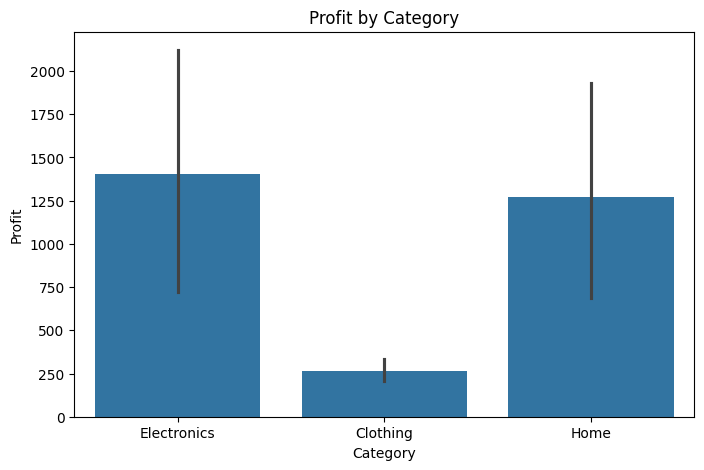

In [ ]:
# PROFIT BY CATEGORY

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Profit', data=df)
plt.title("Profit by Category")
plt.show()

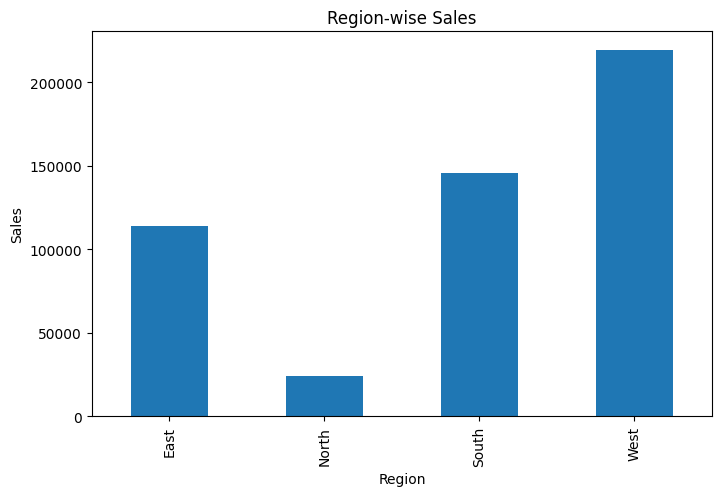

In [ ]:
# REGION-WISE SALES

region_sales=df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar', figsize=(8,5))
plt.title("Region-wise Sales")
plt.ylabel("Sales")
plt.show()

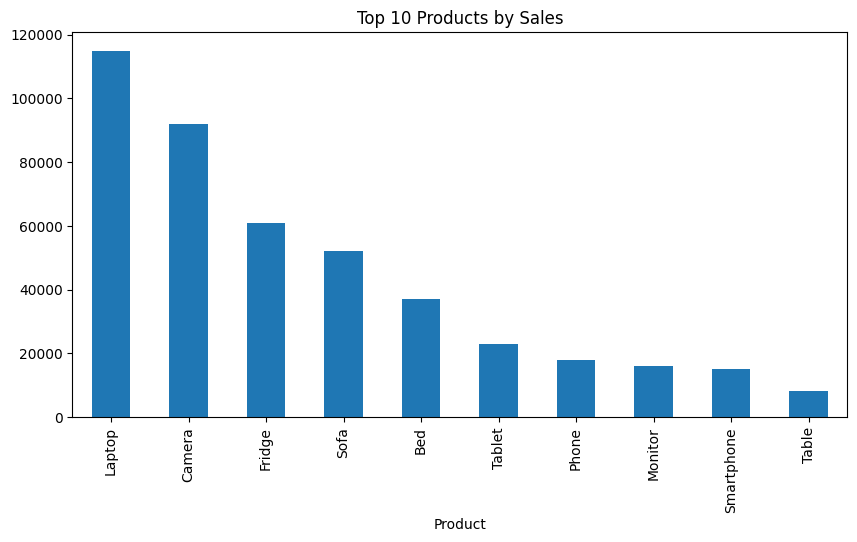

In [ ]:
# TOP PRODUCTS

top_products=df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Sales")
plt.show()

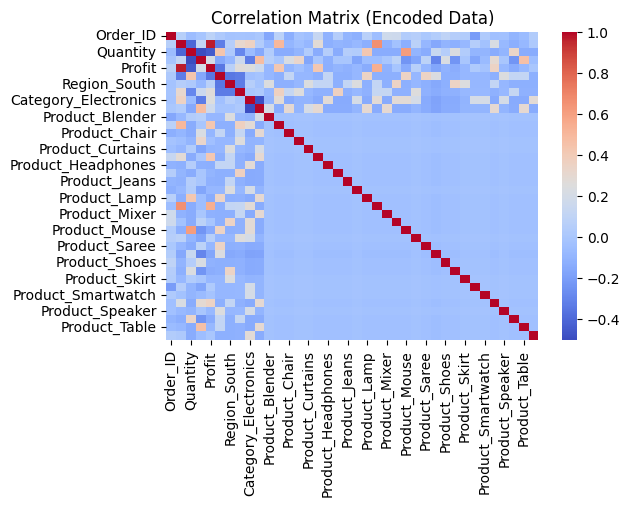

In [ ]:
# CORRELATION ANALYSIS

plt.figure(figsize=(6,4))
sns.heatmap(df_encoded.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix (Encoded Data)")
plt.show()

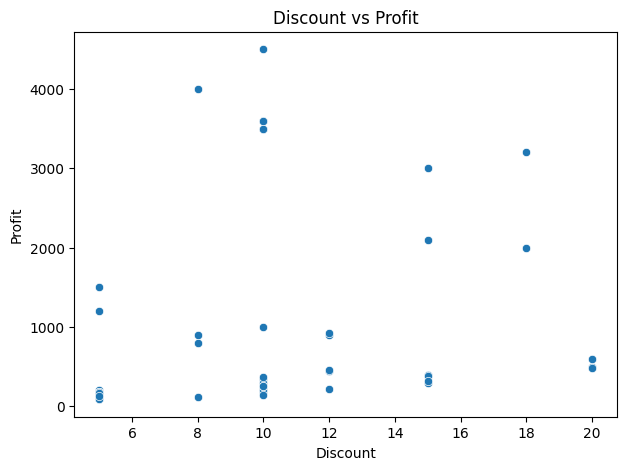

In [ ]:
# DISCOUNT VS PROFIT RELATIONSHIP

plt.figure(figsize=(7,5))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title("Discount vs Profit")
plt.show()

In [ ]:
# DEFINE FEATURES (x) AND TARGET (y)

x = df.drop(['Sales', 'Order_ID', 'Date'], axis=1)
y = df['Sales']

In [ ]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [ ]:
# ENCODE AFTER SPLIT

x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [ ]:
# TRAIN MODEL

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(x_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [ ]:
# FEATURE IMPORTANCE

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

                 Feature  Importance
2                 Profit    0.914261
7          Category_Home    0.034953
6   Category_Electronics    0.021196
9         Product_Camera    0.006272
13        Product_Fridge    0.006065
5            Region_West    0.005933
19        Product_Laptop    0.004778
1               Discount    0.002840
4           Region_South    0.002255
28    Product_Smartphone    0.000394


In [ ]:
# PREDICTION

y_pred = model.predict(x_test)

In [ ]:
# EVALUATION

from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print("R² Score:", score)

R² Score: 0.9592803155329499


In [ ]:
# BUSINESS INSIGHT OUTPUT

print("\n--- BUSINESS INSIGHTS ---")
print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())

print("Most Profitable Category:", df.groupby('Category')['Profit'].sum().idxmax())
print("Best Region:", df.groupby('Region')['Sales'].sum().idxmax())

print("Average Discount Impact on Profit:",
      df.groupby('Discount')['Profit'].mean().sort_values().head(3))

print("Highest Average Discount Applied:",
      df.groupby('Category')['Discount'].mean().idxmax())


--- BUSINESS INSIGHTS ---
Total Sales: 503830
Total Profit: 48730
Most Profitable Category: Electronics
Best Region: West
Average Discount Impact on Profit: Discount
5     315.714286
20    526.666667
12    590.000000
Name: Profit, dtype: float64
Highest Average Discount Applied: Home
